In [1]:
# Math modules
import pandas as pd
import numpy as np

# Neural networt modules for creating RNN
import torch
import torch.nn as nn

# Plotting modules
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
# Gathering dataset
dataset = pd.read_csv("malicious_phish.csv")
print(dataset)
dataset["type"].value_counts()

                                                      url        type
0                                        br-icloud.com.br    phishing
1                     mp3raid.com/music/krizz_kaliko.html      benign
2                         bopsecrets.org/rexroth/cr/1.htm      benign
3       http://www.garage-pirenne.be/index.php?option=...  defacement
4       http://adventure-nicaragua.net/index.php?optio...  defacement
...                                                   ...         ...
651186            xbox360.ign.com/objects/850/850402.html    phishing
651187       games.teamxbox.com/xbox-360/1860/Dead-Space/    phishing
651188         www.gamespot.com/xbox360/action/deadspace/    phishing
651189      en.wikipedia.org/wiki/Dead_Space_(video_game)    phishing
651190          www.angelfire.com/goth/devilmaycrytonite/    phishing

[651191 rows x 2 columns]


type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

In [3]:
# Making all links lowercased
def lowercaseURLs(urlCol):
    return urlCol.str.lower()

dataset["lowercase_url"] = lowercaseURLs(dataset["url"])
dataset

,url,type,lowercase_url
0,br-icloud.com.br,phishing,br-icloud.com.br
1,mp3raid.com/music/krizz_kaliko.html,benign,mp3raid.com/music/krizz_kaliko.html
2,bopsecrets.org/rexroth/cr/1.htm,benign,bopsecrets.org/rexroth/cr/1.htm
3,http://www.garage-pirenne.be/index.php?option=...,defacement,http://www.garage-pirenne.be/index.php?option=...
4,http://adventure-nicaragua.net/index.php?optio...,defacement,http://adventure-nicaragua.net/index.php?optio...
...,...,...,...
651186,xbox360.ign.com/objects/850/850402.html,phishing,xbox360.ign.com/objects/850/850402.html
651187,games.teamxbox.com/xbox-360/1860/Dead-Space/,phishing,games.teamxbox.com/xbox-360/1860/dead-space/
651188,www.gamespot.com/xbox360/action/deadspace/,phishing,www.gamespot.com/xbox360/action/deadspace/
651189,en.wikipedia.org/wiki/Dead_Space_(video_game),phishing,en.wikipedia.org/wiki/dead_space_(video_game)


In [4]:
# Counting the number of unique characters and categories throughout the whole data set
allChars = set(''.join(dataset["lowercase_url"]))
allCategories = list(dataset["type"].unique())
n_chars = len(allChars)
n_categories = len(allCategories)

charToIndex = {c: i for i, c in enumerate(allChars)}
indexToChar = {i: c for c, i in enumerate(allChars)}

print(allChars)
print(allCategories)
print(n_chars, "characters total")
print(n_categories, "categories total")

{'\x0c', '¬', '|', 'ô', '\r', 'þ', 'ฦ', '§', '\x1e', 'ุ', 'ž', '6', 'o', 'ฎ', 'â', 'r', '•', '\xa0', 'ิ', '\x94', '™', '&', '\x01', 'า', '\x0f', '\x86', '\n', '¯', '\x9a', '¾', '$', 'x', '\x04', '傅', '\x87', 'c', '‚', 'ฺ', '½', '{', 'ช', '\x17', 'z', '°', 'ã', '¨', '@', 'j', '\x8f', 'g', 'ข', '\x10', '¹', '\x12', 'ธ', '\x84', 'ù', 'ว', '.', '\x92', 'ญ', 'ฤ', 'º', '’', '(', '3', 'ˆ', 'u', 'k', '¡', '®', '\x03', '\x99', 'ƒ', 'ส', '\x11', 'é', 'ฏ', '#', '\x16', 'ö', '\x81', '×', '”', '*', 'ถ', '�', '¸', '\x96', '\x08', 'ฑ', 'น', 'บ', 'û', '拠', ']', ',', 'ศ', '\xad', '\x02', '_', '-', '+', '"', '÷', 'ฐ', 'm', '\uf1dc', '¦', '\x9d', '¶', '\x9b', 'ฃ', '\x9c', '\x9e', '\x93', 'ๅ', 'è', 'ç', '\x91', 'w', ')', '¿', '\x1a', 'l', 'ย', 'à', '»', 'ฉ', '่', 'ห', 'í', '\x88', '\x1d', '³', 'e', '\x7f', 'y', ':', '\x98', '±', '\x0e', '—', '´', '\x15', 'd', '¥', '\x1f', 'ง', '\x13', '2', 'ต', '/', '5', 'เ', 'á', 'n', '\x07', '\x97', '>', '©', 'õ', 'ั', 'ñ', '\x1c', '1', 'ฝ', '}', '\x0b', 'ค', '=', '·', 

In [5]:
# Defining the recurrent neural network (may differ from Assignment 4's RNN)
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        
        self.rnn_cell = nn.RNNCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)
    
    def forward(self, x):
        """
        x: size [seq_length, 1, input_size]
        """
        h = torch.zeros(x.size(1), self.hidden_size)
        
        for i in range(x.size(0)):
            h = self.rnn_cell(x[i], h)
        
        out = self.softmax(self.fc(h))
        return out

In [6]:
import time
import math
import random
random.seed(0)

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return f'{m}m {s:.2f}s'

# Convert letter to index for faster lookup
def letterToIndex(letter):
    return charToIndex[letter]

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_chars)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

# Make category into tensor
def categoryToTensor(category):
    li = allCategories.index(category)
    tensor = torch.tensor([li], dtype=torch.long)
    return tensor

# To interpret the output of the network, use Tensor.topk to get the index of the greatest value
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return list(allCategories)[category_i], category_i

In [7]:
# Iteratively training RNN model
def train(model, n_iters = 10000, print_every = 500, plot_every = 125, learning_rate = 0.005):

    # Counts the number of true positives, false positives, true negatives, and false negatives

    tp = 0  # True positives are counted when the model correctly predicts a malicious (or non-benign) URL
    fp = 0  # False positives are counted when the model incorrectly predicts a benign URL as malicious
    tn = 0  # True negatives are counted when the model correctly predicts a benign URL
    fn = 0  # False negatives are counted when the model incorrectly predicts a malicious URL as benign

    # Turn on the training model
    model.train()
    
    # Loss and optimizer
    criterion = nn.NLLLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    
    running_loss = 0
    all_losses = []
    
    # Train loop
    start = time.time()
    for i in range(n_iters):
        # Sample a randmon row from the dataset
        currSample = dataset.iloc[random.randint(0, len(dataset) - 1)]

        # Get input and target tensors from the sample
        x = currSample["lowercase_url"]
        y = currSample["type"]
        x_tensor = lineToTensor(x)
        y_tensor = categoryToTensor(y)
        
        # Zero gradient
        optimizer.zero_grad()
        
        # Forward pass
        output = model(x_tensor)
        loss = criterion(output, y_tensor)
        
        # Backprop and update
        loss.backward()
        optimizer.step()
        
        # Record loss
        running_loss += loss.item()
        
        # Get guess from output and compute metrics
        isBenign = (y == "benign")
        guess, guess_i = categoryFromOutput(output)

        if guess == y:
            if isBenign:
                tn += 1
            else:
                tp += 1
        else:
            if isBenign:
                fp += 1
            else:
                fn += 1
        
        # Print iter, loss, name, and guess; also update confusion matrix metrics
        if i % print_every == 0 and i > 0:
            correct = '✓' if guess == y else '✗ (%s)' % y
            print('%d %d%% (%s) %.4f %s / %s %s' % (i, i / n_iters * 100, timeSince(start), loss, x, guess, correct))
        
        # Append loss
        if i % plot_every == 0 and i > 0:
            all_losses.append(running_loss / plot_every)
            running_loss = 0
    
    print()

    # Print evaluation metrics on the training set
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"100% Training Complete! Ran on {n_iters} iterations.")
    print('Final Evaluation Metrics on Training Set:')
    print(f'Accuracy: {accuracy:.2f}')
    print(f'Precision: {precision:.2f}')
    print(f'Recall: {recall:.2f}')
    print(f'False Positive Rate: {false_positive_rate:.2f}')
    print(f'F1 Score: {f1_score:.2f}')

    # Plot for losses
    plt.figure()
    plt.plot(all_losses)

/tmp/ipykernel_38970/2744913434.py:65: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  print('%d %d%% (%s) %.4f %s / %s %s' % (i, i / n_iters * 100, timeSince(start), loss, x, guess, correct))


500 5% (0m 18.95s) 0.5756 homevideo.about.com/library/bl_herculess2.htm / benign ✓
1000 10% (0m 35.83s) 1.7043 http://www.productiva.com.br/index.php?option=com_mailto&tmpl=component&link=ahr0cdovl3d3dy5wcm9kdwn0axzhlmnvbs5ici9pbmrlec5waha%2fb3b0aw9upwnvbv9jb250zw50jnzpzxc9yxj0awnszszpzd0xmdmlm0fvympldgl2b3mtzgutdw0tzgf0ys13yxjlag91c2umy2f0awq9ndmlm0fwcm9kdwn0axzhjkl0zw1pzd0xntu= / benign ✗ (defacement)
1500 15% (1m 2.94s) 0.4143 amazon.com/dead-flowers-bottles-bluegrass-bones/dp/b000089ixm / benign ✓
2000 20% (1m 27.06s) 2.0639 commbank.com.au.suehadow.co.uk / benign ✗ (phishing)
2500 25% (1m 45.03s) 1.7900 www.wjduquette.com/tcl/ / benign ✗ (phishing)
3000 30% (2m 11.44s) 3.0104 http://3cf.ru/2015/07/21/eksperty-proveriat-realnost-pokazanii-glavnogo-figyranta-dela-nemcova/ / benign ✗ (malware)
3500 35% (2m 37.88s) 0.5190 mcclelland.com/author/results.pperl?authorid=9609 / benign ✓
4000 40% (3m 7.15s) 0.2901 citymelt.com/county/new-jersey/morris+county-nj.html / benign ✓
4500 45% (3m 

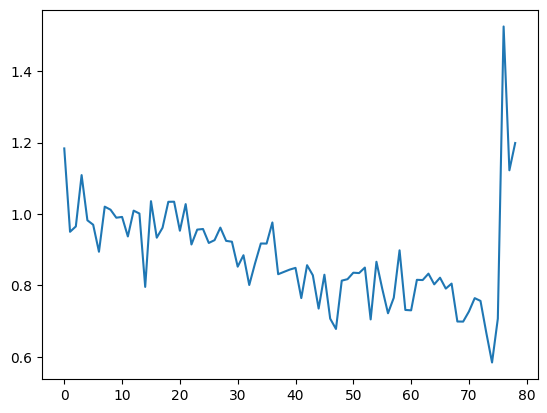

In [8]:
# Evaluate the RNN model
import random
### DO NOT CHANGE THE CODE BELOW ###
torch.manual_seed(0)
random.seed(0)

n_hidden = 128
rnn = RNN(n_chars, n_hidden, n_categories)

train(rnn)